# Session 2: Short Guide to Parameter Reforms

This notebook is a compact version of the GETTSIM guide on modifying policy environments.

Workflow:
1. Build status-quo policy environment.
2. Run baseline output.
3. Copy the environment and replace one parameter.
4. Re-run and compare baseline vs reform.

Reference how-to guide (full version):
https://gettsim.readthedocs.io/en/stable/how_to_guides/modifications_of_policy_environments.html

## 0) Setup

In [ ]:
# Command for installing gettsim (only use on Colab)

# !apt-get update -qq
# !apt-get install -y graphviz graphviz-dev pkg-config
# !pip install pygraphviz
# !pip install gettsim
# !pip install git+https://github.com/ttsim-dev/gettsim-personas.git

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gettsim import InputData, MainTarget, TTTargets, copy_environment, main
from gettsim.tt import ScalarParam

In [2]:
POLICY_DATE = "2025-01-01"

### Parameter object types in GETTSIM

In this notebook we modify a **ScalarParam**. Besides scalar parameters, GETTSIM also uses other parameter object types:
- `DictParam`
- `ConsecutiveIntLookupTableParam`
- `PiecewisePolynomialParam`
- `RawParam`

The same workflow applies: inspect -> copy environment -> replace object -> rerun.

## 1) Status quo environment and baseline run

In [3]:
from gettsim_personas import einkommensteuer_sozialabgaben

# Use a stable, fully specified persona so we can focus on policy changes,
# not on missing-input debugging in this session.

persona = einkommensteuer_sozialabgaben.Couple1Child(policy_date_str=POLICY_DATE)
print(persona.description)

Persona to compute income taxes and social insurance contributions. Jointly
        taxed married couple with one child. All transfers are set to zero; don't use
        this persona for low- to mid-income households, as they may be eligible for
        (means-tested) transfers.


In [4]:
# Keep target scope narrow so the policy effect is easy to interpret.
tt_targets = TTTargets(tree={"einkommensteuer": {"betrag_y_sn": None}})

In [5]:
# Build the policy environment object for the selected date.
# This is our baseline 'law as of date' object.
status_quo_environment = main(
    main_target=MainTarget.policy_environment,
    policy_date_str=POLICY_DATE,
    include_warn_nodes=False,
)

In [6]:
# Baseline simulation under status-quo environment.
baseline = main(
    main_target=MainTarget.results.df_with_nested_columns,
    policy_date_str=POLICY_DATE,
    input_data=InputData.tree(tree=persona.input_data_tree),
    tt_targets=tt_targets,
    include_warn_nodes=False,
)

baseline

,einkommensteuer
,betrag_y_sn
p_id,
0,7120.0
1,7120.0
2,0.0


## 2) Inspect and modify one parameter

We modify `arbeitnehmerpauschbetrag` (a scalar parameter).

In [7]:
# Inspect the full parameter object (metadata + value).
status_quo_environment["einkommensteuer"]["einkünfte"]["aus_nichtselbstständiger_arbeit"]["arbeitnehmerpauschbetrag"]

ScalarParam(start_date=datetime.date(2023, 1, 1), end_date=datetime.date(2099, 12, 31), unit='Euros', reference_period='Year', name={'de': 'Arbeitnehmerpauschbetrag bei nichtselbstständiger Arbeit.', 'en': 'Lump-sum deduction for employment income.'}, description={'de': '§ 9a Nr. 1a) EStG', 'en': 'This is the minimum amount deducted from any employment income.'}, value=1230, note=None, reference='G. v. 20.12.2022 BGBl. I S. 2294.')

In [8]:
# Extract only the numeric value used in calculations.
status_quo_environment["einkommensteuer"]["einkünfte"]["aus_nichtselbstständiger_arbeit"]["arbeitnehmerpauschbetrag"].value

1230

In [9]:
# Always copy before modifying: avoids accidental in-place edits of baseline.
reform_environment = copy_environment(status_quo_environment)

# Replace one scalar parameter object with a reformed value.
reform_environment["einkommensteuer"]["einkünfte"]["aus_nichtselbstständiger_arbeit"]["arbeitnehmerpauschbetrag"] = ScalarParam(value=1600)

## 3) Re-run with reformed environment

In [10]:
# Re-run with the modified policy environment.
reform = main(
    main_target=MainTarget.results.df_with_nested_columns,
    policy_date_str=POLICY_DATE,
    input_data=InputData.tree(tree=persona.input_data_tree),
    tt_targets=tt_targets,
    policy_environment=reform_environment,
    include_warn_nodes=False,
)

reform

,einkommensteuer
,betrag_y_sn
p_id,
0,6917.0
1,6917.0
2,0.0


## 4) Loop over `arbeitnehmerpauschbetrag` and plot tax

We now run a small policy sweep: vary `arbeitnehmerpauschbetrag` and record the resulting income tax.

In [11]:
pauschbetrag_grid = np.arange(1000, 2601, 100)
rows = []

for pauschbetrag in pauschbetrag_grid:
    env = copy_environment(status_quo_environment)
    env["einkommensteuer"]["einkünfte"]["aus_nichtselbstständiger_arbeit"]["arbeitnehmerpauschbetrag"] = ScalarParam(
        value=float(pauschbetrag)
    )

    out = main(
        main_target=MainTarget.results.df_with_nested_columns,
        policy_date_str=POLICY_DATE,
        input_data=InputData.tree(tree=persona.input_data_tree),
        tt_targets=tt_targets,
        policy_environment=env,
        include_warn_nodes=False,
    )

    # Use p_id 0 as reference person for the chart.
    tax_value = float(out.loc[0, ("einkommensteuer", "betrag_y_sn")])
    rows.append({"arbeitnehmerpauschbetrag": float(pauschbetrag), "tax_p0": tax_value})

sweep_df = pd.DataFrame(rows)
sweep_df

,arbeitnehmerpauschbetrag,tax_p0
0,1000.0,7246.0
1,1100.0,7191.0
2,1200.0,7136.0
3,1300.0,7081.0
4,1400.0,7027.0
5,1500.0,6972.0
6,1600.0,6917.0
7,1700.0,6862.0
8,1800.0,6808.0
9,1900.0,6753.0


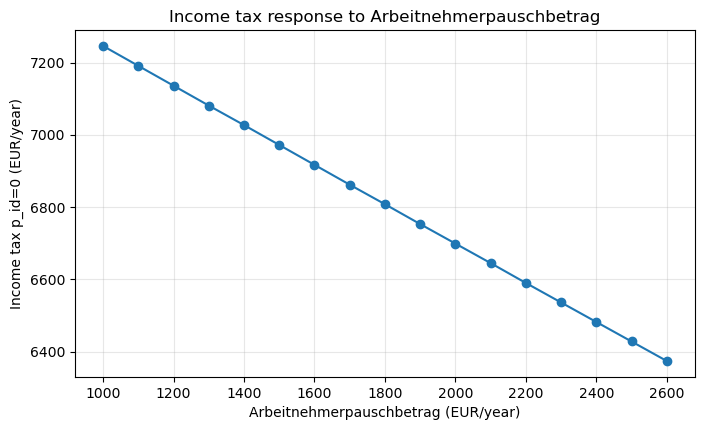

In [12]:
plt.figure(figsize=(8, 4.5))
plt.plot(sweep_df["arbeitnehmerpauschbetrag"], sweep_df["tax_p0"], marker="o")
plt.xlabel("Arbeitnehmerpauschbetrag (EUR/year)")
plt.ylabel("Income tax p_id=0 (EUR/year)")
plt.title("Income tax response to Arbeitnehmerpauschbetrag")
plt.grid(True, alpha=0.3)
plt.show()